send finns: True
rec finns : True

Vald modell: Bohus
R_ref = 1.257525 Ω
X_ref = 6.555000 Ω
alpha = 0.00403 1/K
T_ref = 20.0 °C


C:\Users\lundi\AppData\Local\Temp\ipykernel_153016\1128784898.py:101: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  D["Timestamp"] = pd.to_datetime(D["Timestamp"], errors="coerce")
C:\Users\lundi\AppData\Local\Temp\ipykernel_153016\1128784898.py:101: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  D["Timestamp"] = pd.to_datetime(D["Timestamp"], errors="coerce")


joined rows: 7669
start: 2025-12-11 15:25:02.469999 slut: 2025-12-11 15:27:32.450000


,Scenario,Phase,R_mean_Ohm,R_std_Ohm,X_mean_Ohm,X_std_Ohm,T_mean_C,T_std_C,dU_mean_deg,dI_mean_deg,P_send_mean_W,P_rec_mean_W
0,actual,L1,1.784722,0.013036,6.716446,0.020233,124.028320,2.572391,8.987698e-01,9.844171e-01,1.546604e+07,1.524867e+07
1,actual,L2,1.114641,0.011302,6.244582,0.018772,-8.194314,2.230181,8.759890e-01,9.545637e-01,1.627749e+07,1.605842e+07
2,actual,L3,0.509709,0.014160,6.713966,0.020318,-127.561448,2.794064,8.987592e-01,1.459783e+00,1.551126e+07,1.527066e+07
3,bias_zero,L1,2.035839,0.073250,0.065074,0.246198,173.579474,14.453957,-5.641971e-15,-9.331400e-16,1.546604e+07,1.524951e+07
4,bias_zero,L2,1.581367,0.077810,0.110688,0.217312,83.901487,15.353779,-1.891578e-15,-6.692067e-15,1.627749e+07,1.606007e+07
5,bias_zero,L3,1.270824,0.098305,0.131682,0.232570,22.624159,19.397952,3.415707e-15,-2.340735e-15,1.551126e+07,1.528781e+07
6,perfect,L1,2.032001,0.063210,0.075131,0.024641,172.822153,12.472809,0.000000e+00,0.000000e+00,1.546604e+07,1.524961e+07
7,perfect,L2,1.577609,0.060113,0.119064,0.021835,83.159966,11.861773,0.000000e+00,0.000000e+00,1.627749e+07,1.606025e+07
8,perfect,L3,1.266229,0.071222,0.140591,0.022699,21.717431,14.053667,0.000000e+00,0.000000e+00,1.551126e+07,1.528815e+07


Sparat till: C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\JÄMFÖRELSE_actual_vs_bias_zero_vs_perfect_angles


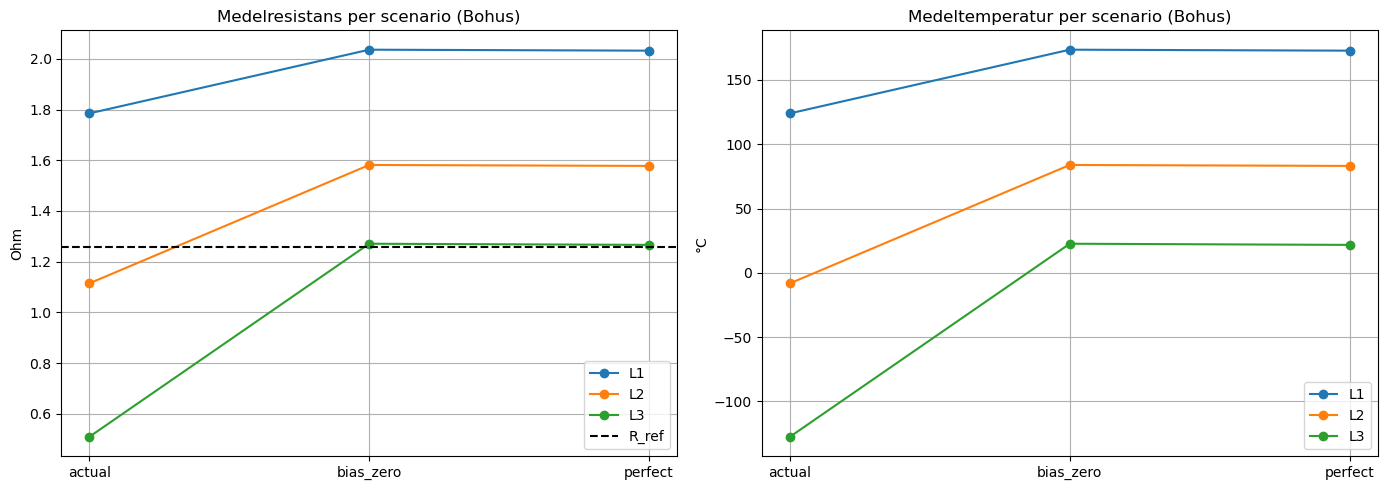

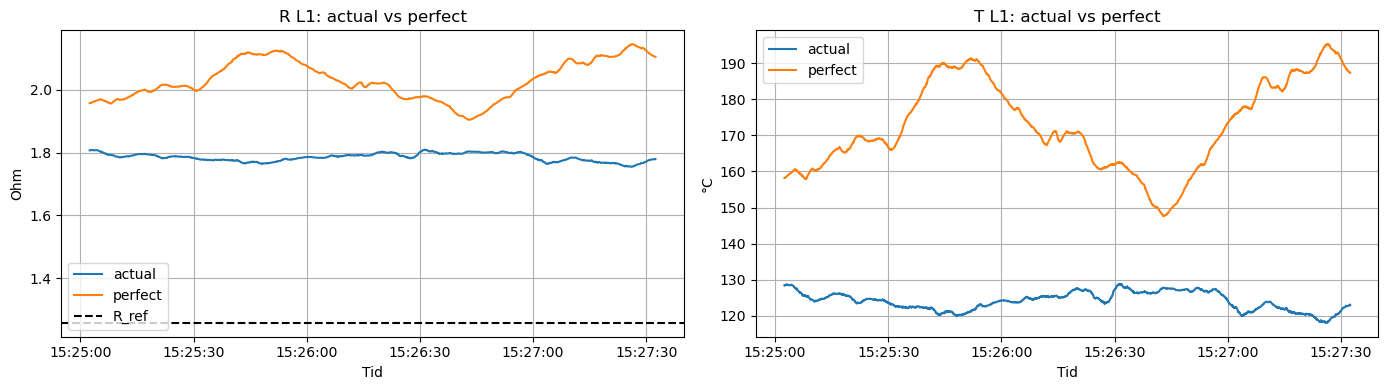

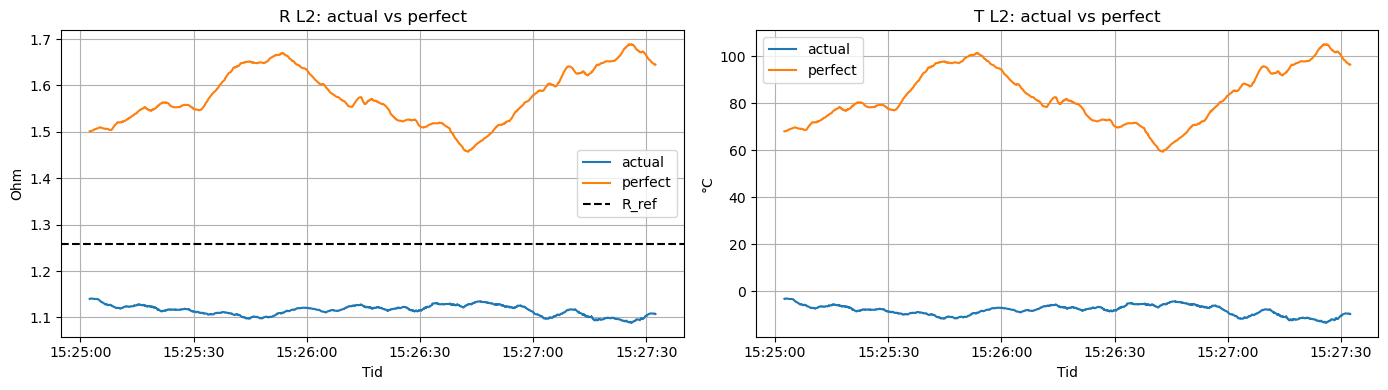

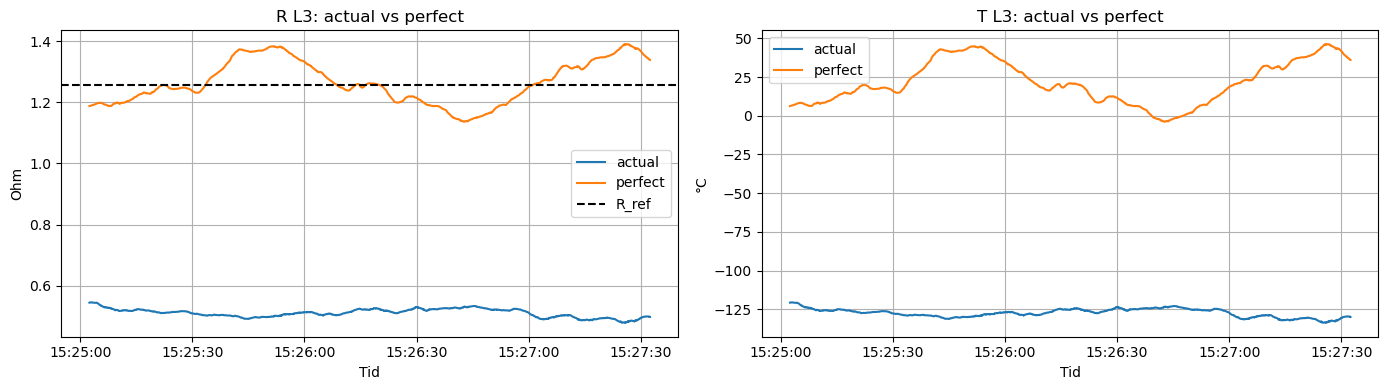

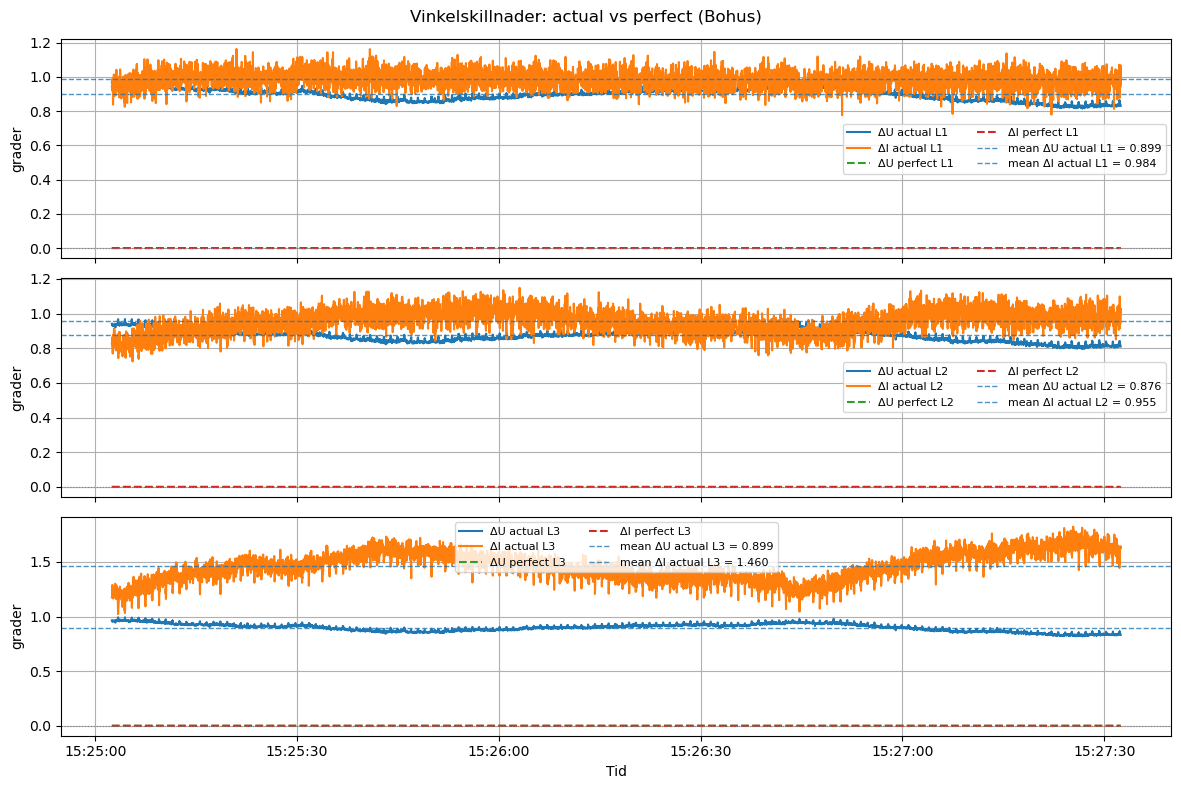

In [2]:
# ============================================================
# JÄMFÖRELSE: actual vs bias_zero vs perfect angles
# Z-drop -> R -> T
# ============================================================

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.options.mode.chained_assignment = None

# ============================================================
# FILVÄGAR OCH BLADNAMN
# ============================================================

send_file = Path(r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\send-station.xlsx")
rec_file  = Path(r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\rec-station.xlsx")

keyS_sheet  = "K-nyckel"
dataS_sheet = "Station_K_3x15000"

keyR_sheet  = "F-nyckel"
dataR_sheet = "Station_F_3x15000"

print("send finns:", send_file.exists())
print("rec finns :", rec_file.exists())

# ============================================================
# MODELLVAL
# ============================================================

MODEL = "Bohus"   # byt till "Gota" om du vill

MODELS = {
    "Bohus": {
        "length_km": 17.25,
        "RAC_ohm_per_km": 0.0729,
        "alpha": 0.00403,
        "T_ref_C": 20.0,
        "X_ohm_per_km": 0.38,
    },
    "Gota": {
        "length_km": 21.95,
        "RAC_ohm_per_km": 0.0348,
        "alpha": 0.00403,
        "T_ref_C": 20.0,
        "X_ohm_per_km": 0.38,
    },
}

model = MODELS[MODEL]
R_ref = model["RAC_ohm_per_km"] * model["length_km"]
X_ref = model["X_ohm_per_km"] * model["length_km"]
alpha = model["alpha"]
T_ref = model["T_ref_C"]

print(f"\nVald modell: {MODEL}")
print(f"R_ref = {R_ref:.6f} Ω")
print(f"X_ref = {X_ref:.6f} Ω")
print(f"alpha = {alpha:.5f} 1/K")
print(f"T_ref = {T_ref:.1f} °C")

# ============================================================
# PARAMETRAR
# ============================================================

smooth_seconds = 2.0
min_current_A = 50.0

# ============================================================
# HJÄLPFUNKTIONER
# ============================================================

def wrap_angle_deg(angle_deg):
    return (angle_deg + 180.0) % 360.0 - 180.0

def circular_mean_deg(angle_deg):
    angle_deg = np.asarray(angle_deg, dtype=float)
    angle_deg = angle_deg[~np.isnan(angle_deg)]
    if len(angle_deg) == 0:
        return np.nan
    angle_rad = np.deg2rad(angle_deg)
    return np.rad2deg(np.angle(np.mean(np.exp(1j * angle_rad))))

def read_key_table_safe(filename, sheetname):
    T = pd.read_excel(filename, sheet_name=sheetname, header=None)
    T = T.iloc[:, :2].copy()
    T.columns = ["Parameter", "ID"]
    T = T.dropna(how="all")
    T["Parameter"] = T["Parameter"].astype(str).str.strip()
    T["ID"] = T["ID"].astype(str).str.strip()
    return T

def read_data_table_safe(filename, sheetname):
    D = pd.read_excel(filename, sheet_name=sheetname, header=None)
    D = D.iloc[:, :3].copy()
    D.columns = ["Timestamp", "ID", "Value"]
    D["Timestamp"] = pd.to_datetime(D["Timestamp"], errors="coerce")
    D["ID"] = D["ID"].astype(str).str.strip()
    D["Value"] = (
        D["Value"]
        .astype(str)
        .str.strip()
        .str.replace(",", ".", regex=False)
    )
    D["Value"] = pd.to_numeric(D["Value"], errors="coerce")
    D = D.dropna(subset=["Timestamp"])
    return D

def complex_from_mag_ang(mag, ang_deg):
    return mag * np.exp(1j * np.deg2rad(ang_deg))

def rolling_complex_mean(z, window):
    z_re = pd.Series(np.real(z), index=z.index).rolling(window=window, center=True, min_periods=1).mean()
    z_im = pd.Series(np.imag(z), index=z.index).rolling(window=window, center=True, min_periods=1).mean()
    return z_re + 1j * z_im

def add_mean_line(ax, y, color=None, label_prefix="mean", circular=False):
    if circular:
        mean_val = circular_mean_deg(y)
    else:
        mean_val = np.nanmean(y)
    ax.axhline(mean_val, linestyle="--", linewidth=1.0, color=color, alpha=0.8,
               label=f"{label_prefix} = {mean_val:.3f}")
    return mean_val

def build_joined_dataframe():
    keyS = read_key_table_safe(send_file, keyS_sheet)
    keyR = read_key_table_safe(rec_file, keyR_sheet)

    send = read_data_table_safe(send_file, dataS_sheet)
    rec  = read_data_table_safe(rec_file, dataR_sheet)

    send = send.merge(keyS, on="ID", how="inner")
    rec  = rec.merge(keyR, on="ID", how="inner")

    wideS = send.pivot_table(index="Timestamp", columns="Parameter", values="Value", aggfunc="first")
    wideR = rec.pivot_table(index="Timestamp", columns="Parameter", values="Value", aggfunc="first")

    wideS = wideS.add_suffix("_S").sort_index()
    wideR = wideR.add_suffix("_R").sort_index()

    df_joined = wideS.join(wideR, how="inner").copy()

    required_cols = []
    for ph in ["L1", "L2", "L3"]:
        required_cols += [
            f"U{ph}MAG_S", f"U{ph}ANG_S", f"U{ph}MAG_R", f"U{ph}ANG_R",
            f"I{ph}MAG_S", f"I{ph}ANG_S", f"I{ph}MAG_R", f"I{ph}ANG_R",
        ]

    missing = [c for c in required_cols if c not in df_joined.columns]
    if missing:
        raise ValueError(f"Saknade kolumner: {missing}")

    df_joined = df_joined.dropna(subset=required_cols).copy()

    # filtrera bort orimliga vinkelvärden
    angle_cols = [c for c in df_joined.columns if "ANG" in c]
    for c in angle_cols:
        df_joined = df_joined[(df_joined[c] >= -180) & (df_joined[c] <= 180)]

    return df_joined

def run_scenario(df_joined, scenario_name="actual"):
    dt = df_joined.index.to_series().diff().dropna().dt.total_seconds()
    fs = 1.0 / dt.median()
    smooth_window = int(round(smooth_seconds * fs))

    out = pd.DataFrame(index=df_joined.index)
    summary_rows = []

    for ph in ["L1", "L2", "L3"]:
        U_mag_S = df_joined[f"U{ph}MAG_S"]
        U_ang_S = df_joined[f"U{ph}ANG_S"]
        U_mag_R = df_joined[f"U{ph}MAG_R"]
        U_ang_R = df_joined[f"U{ph}ANG_R"]

        I_mag_S = df_joined[f"I{ph}MAG_S"]
        I_ang_S = df_joined[f"I{ph}ANG_S"]
        I_mag_R = df_joined[f"I{ph}MAG_R"]
        I_ang_R = df_joined[f"I{ph}ANG_R"]

        # Rå korrigerad mottagarströmvinkel
        I_ang_R_corr_raw = wrap_angle_deg(I_ang_R + 180.0)

        # Scenariodefinition
        if scenario_name == "actual":
            U_ang_R_use = U_ang_R.copy()
            I_ang_R_use = I_ang_R_corr_raw.copy()

        elif scenario_name == "bias_zero":
            dU_mean = circular_mean_deg(wrap_angle_deg(U_ang_S - U_ang_R))
            dI_mean = circular_mean_deg(wrap_angle_deg(I_ang_S - I_ang_R_corr_raw))

            U_ang_R_use = wrap_angle_deg(U_ang_R + dU_mean)
            I_ang_R_use = wrap_angle_deg(I_ang_R_corr_raw + dI_mean)

        elif scenario_name == "perfect":
            # idealisering: mottagarvinklar sätts lika med sändarvinklar
            U_ang_R_use = U_ang_S.copy()
            I_ang_R_use = I_ang_S.copy()

        else:
            raise ValueError("scenario_name måste vara 'actual', 'bias_zero' eller 'perfect'")

        # Bygg komplexa storheter
        Vs = complex_from_mag_ang(U_mag_S, U_ang_S)
        Vr = complex_from_mag_ang(U_mag_R, U_ang_R_use)

        Is = complex_from_mag_ang(I_mag_S, I_ang_S)
        Ir = complex_from_mag_ang(I_mag_R, I_ang_R_use)

        # Aktiv effekt (mest för referens)
        P_send = np.real(Vs * np.conj(Is))
        P_rec  = np.real(Vr * np.conj(Ir))

        # Z-drop
        dV = Vs - Vr
        I_avg = 0.5 * (Is + Ir)

        dV_smooth = rolling_complex_mean(pd.Series(dV, index=df_joined.index), smooth_window)
        I_avg_smooth = rolling_complex_mean(pd.Series(I_avg, index=df_joined.index), smooth_window)

        I_abs = np.abs(I_avg_smooth)
        valid = I_abs > min_current_A

        Z_est = pd.Series(np.nan + 1j*np.nan, index=df_joined.index, dtype=complex)
        Z_est.loc[valid] = dV_smooth.loc[valid] / I_avg_smooth.loc[valid]

        R_est = np.real(Z_est)
        X_est = np.imag(Z_est)
        T_est = ((R_est / R_ref) - 1.0) / alpha + T_ref

        dU = wrap_angle_deg(U_ang_S - U_ang_R_use)
        dI = wrap_angle_deg(I_ang_S - I_ang_R_use)

        out[f"U_ang_S_{ph}"] = U_ang_S
        out[f"U_ang_R_use_{ph}"] = U_ang_R_use
        out[f"I_ang_S_{ph}"] = I_ang_S
        out[f"I_ang_R_use_{ph}"] = I_ang_R_use

        out[f"P_send_{ph}"] = P_send
        out[f"P_rec_{ph}"] = P_rec
        out[f"R_{ph}"] = R_est
        out[f"X_{ph}"] = X_est
        out[f"T_{ph}"] = T_est
        out[f"ΔU_deg_{ph}"] = dU
        out[f"ΔI_deg_{ph}"] = dI

        summary_rows.append({
            "Scenario": scenario_name,
            "Phase": ph,
            "R_mean_Ohm": np.nanmean(R_est),
            "R_std_Ohm": np.nanstd(R_est),
            "X_mean_Ohm": np.nanmean(X_est),
            "X_std_Ohm": np.nanstd(X_est),
            "T_mean_C": np.nanmean(T_est),
            "T_std_C": np.nanstd(T_est),
            "dU_mean_deg": circular_mean_deg(dU),
            "dI_mean_deg": circular_mean_deg(dI),
            "P_send_mean_W": np.nanmean(P_send),
            "P_rec_mean_W": np.nanmean(P_rec),
        })

    out["P_total_send"] = out[[f"P_send_{ph}" for ph in ["L1", "L2", "L3"]]].sum(axis=1)
    out["P_total_rec"] = out[[f"P_rec_{ph}" for ph in ["L1", "L2", "L3"]]].sum(axis=1)

    summary_df = pd.DataFrame(summary_rows)
    return out, summary_df

# ============================================================
# 1. KÖR ANALYS
# ============================================================

df_joined = build_joined_dataframe()
print("joined rows:", len(df_joined))
print("start:", df_joined.index.min(), "slut:", df_joined.index.max())

out_actual, summary_actual = run_scenario(df_joined, "actual")
out_bias, summary_bias = run_scenario(df_joined, "bias_zero")
out_perfect, summary_perfect = run_scenario(df_joined, "perfect")

summary_all = pd.concat([summary_actual, summary_bias, summary_perfect], ignore_index=True)
display(summary_all)

# ============================================================
# 2. SPARA
# ============================================================

VERSION = "JÄMFÖRELSE_actual_vs_bias_zero_vs_perfect_angles"   # <-- ändra bara denna rad nästa gång

output_dir = send_file.parent / VERSION
output_dir.mkdir(parents=True, exist_ok=True)


df_joined.reset_index().to_excel(output_dir / "df_joined_angle_compare.xlsx", index=False)
out_actual.reset_index().to_excel(output_dir / "results_actual.xlsx", index=False)
out_bias.reset_index().to_excel(output_dir / "results_bias_zero.xlsx", index=False)
out_perfect.reset_index().to_excel(output_dir / "results_perfect.xlsx", index=False)
summary_all.to_excel(output_dir / "summary_angle_compare.xlsx", index=False)
summary_all.to_csv(output_dir / "summary_angle_compare.csv", index=False)

print("Sparat till:", output_dir)

# ============================================================
# 3. PLOTTAR: MEAN R OCH T PER SCENARIO
# ============================================================

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Resistans
for ph in ["L1", "L2", "L3"]:
    tmp = summary_all[summary_all["Phase"] == ph]
    axs[0].plot(tmp["Scenario"], tmp["R_mean_Ohm"], marker="o", label=ph)
axs[0].axhline(R_ref, color="black", linestyle="--", label="R_ref")
axs[0].set_title(f"Medelresistans per scenario ({MODEL})")
axs[0].set_ylabel("Ohm")
axs[0].grid(True)
axs[0].legend()

# Temperatur
for ph in ["L1", "L2", "L3"]:
    tmp = summary_all[summary_all["Phase"] == ph]
    axs[1].plot(tmp["Scenario"], tmp["T_mean_C"], marker="o", label=ph)
axs[1].set_title(f"Medeltemperatur per scenario ({MODEL})")
axs[1].set_ylabel("°C")
axs[1].grid(True)
axs[1].legend()

fig.tight_layout()
fig.savefig(output_dir / "compare_mean_R_T.png", dpi=200)
plt.show()

# ============================================================
# 4. PLOTTAR: TIDSFÖRLOPP ACTUAL VS PERFECT
# ============================================================

for ph in ["L1", "L2", "L3"]:
    fig, axs = plt.subplots(1, 2, figsize=(14, 4))

    axs[0].plot(out_actual.index, out_actual[f"R_{ph}"], label="actual")
    axs[0].plot(out_perfect.index, out_perfect[f"R_{ph}"], label="perfect")
    axs[0].axhline(R_ref, color="black", linestyle="--", label="R_ref")
    axs[0].set_title(f"R {ph}: actual vs perfect")
    axs[0].set_ylabel("Ohm")
    axs[0].grid(True)
    axs[0].legend()

    axs[1].plot(out_actual.index, out_actual[f"T_{ph}"], label="actual")
    axs[1].plot(out_perfect.index, out_perfect[f"T_{ph}"], label="perfect")
    axs[1].set_title(f"T {ph}: actual vs perfect")
    axs[1].set_ylabel("°C")
    axs[1].grid(True)
    axs[1].legend()

    for ax in axs:
        ax.set_xlabel("Tid")

    fig.tight_layout()
    fig.savefig(output_dir / f"compare_actual_perfect_{ph}.png", dpi=200)
    plt.show()

# ============================================================
# 5. PLOTTAR: VINKELSKILLNADER ACTUAL VS PERFECT
# ============================================================

fig, axs = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for i, ph in enumerate(["L1", "L2", "L3"]):
    axs[i].plot(out_actual.index, out_actual[f"ΔU_deg_{ph}"], label=f"ΔU actual {ph}")
    axs[i].plot(out_actual.index, out_actual[f"ΔI_deg_{ph}"], label=f"ΔI actual {ph}")
    axs[i].plot(out_perfect.index, out_perfect[f"ΔU_deg_{ph}"], linestyle="--", label=f"ΔU perfect {ph}")
    axs[i].plot(out_perfect.index, out_perfect[f"ΔI_deg_{ph}"], linestyle="--", label=f"ΔI perfect {ph}")

    add_mean_line(axs[i], out_actual[f"ΔU_deg_{ph}"], label_prefix=f"mean ΔU actual {ph}", circular=True)
    add_mean_line(axs[i], out_actual[f"ΔI_deg_{ph}"], label_prefix=f"mean ΔI actual {ph}", circular=True)

    axs[i].axhline(0, color="gray", linestyle=":", linewidth=0.8)
    axs[i].set_ylabel("grader")
    axs[i].grid(True)
    axs[i].legend(ncol=2, fontsize=8)

axs[-1].set_xlabel("Tid")
fig.suptitle(f"Vinkelskillnader: actual vs perfect ({MODEL})")
fig.tight_layout()
fig.savefig(output_dir / "compare_angles_actual_perfect.png", dpi=200)
plt.show()


PHI OCH COS(PHI):


,Phase,phi_send_mean_deg,phi_rec_mean_deg,cosphi_send_mean,cosphi_rec_mean,phi_send_std_deg,phi_rec_std_deg
0,L1,2.093927,2.179574,0.999271,0.999208,0.635084,0.672977
1,L2,4.287354,4.365929,0.997141,0.997023,0.631091,0.703245
2,L3,6.290655,6.851677,0.993912,0.992758,0.665486,0.813425



FASFÖRSKJUTNING MELLAN L1, L2, L3:


,Signal,L1-L2 mean deg,L2-L3 mean deg,L3-L1 mean deg,L1 rel 0-360,L2 rel 0-360,L3 rel 0-360
0,U_send,119.977424,120.020442,120.002134,0.0,240.022576,120.002134
1,U_rec,119.954643,120.043213,120.002144,0.0,240.045357,120.002144
2,I_send,122.170851,122.023744,115.805405,0.0,237.829149,115.805405
3,I_rec_corr,122.140998,122.528963,115.330039,0.0,237.859002,115.330039


Extra tabeller sparade i: C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\JÄMFÖRELSE_actual_vs_bias_zero_vs_perfect_angles


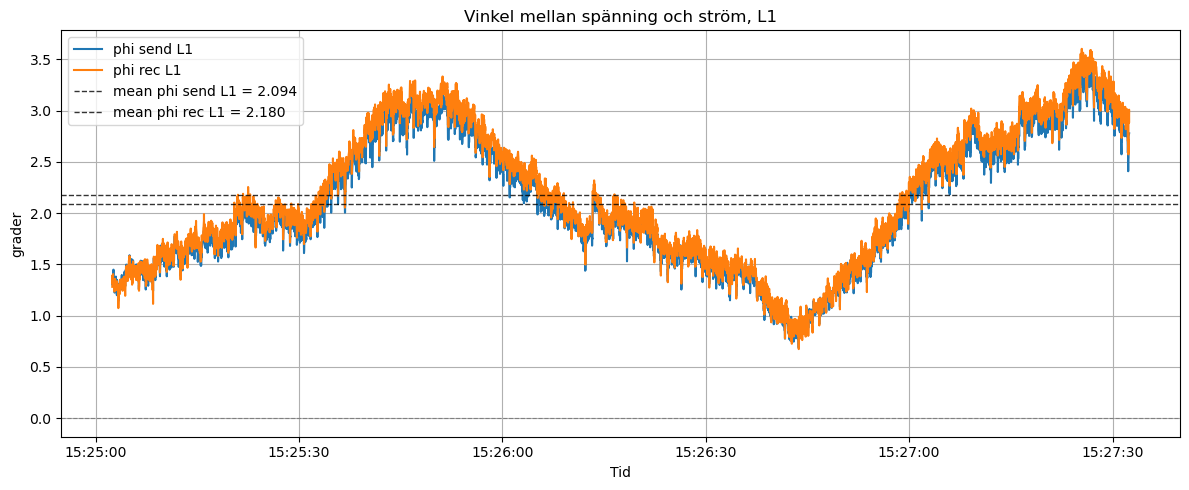

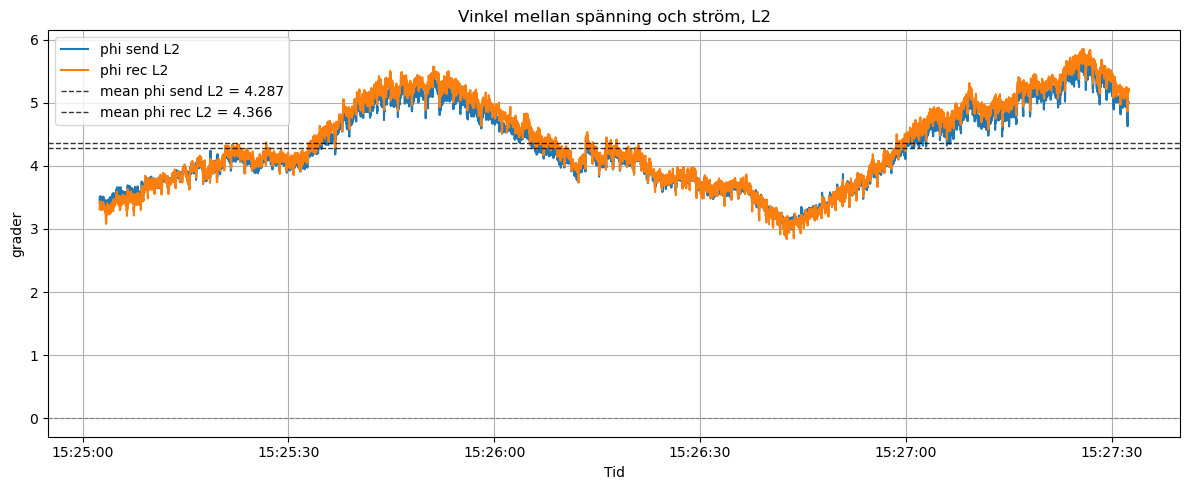

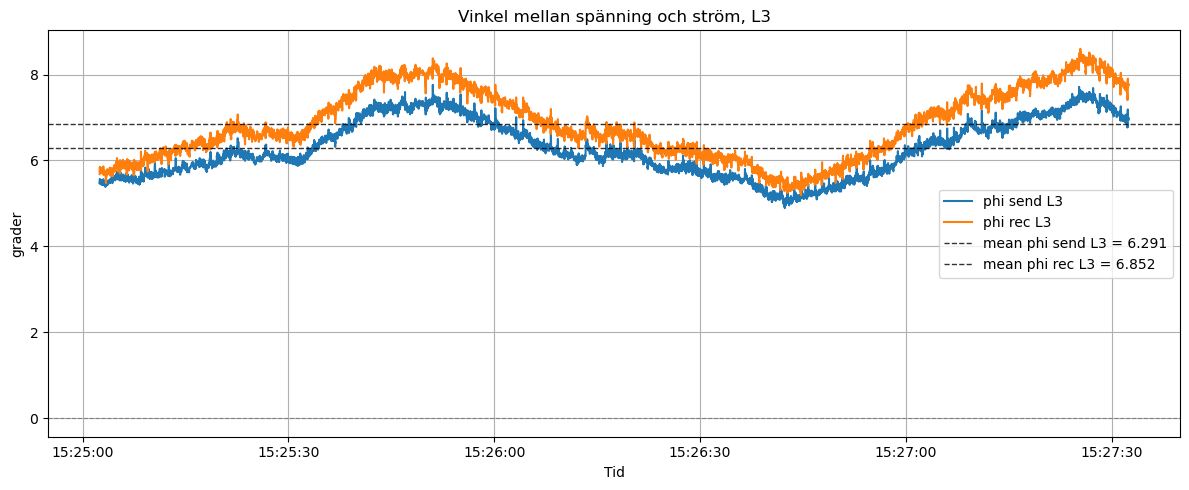

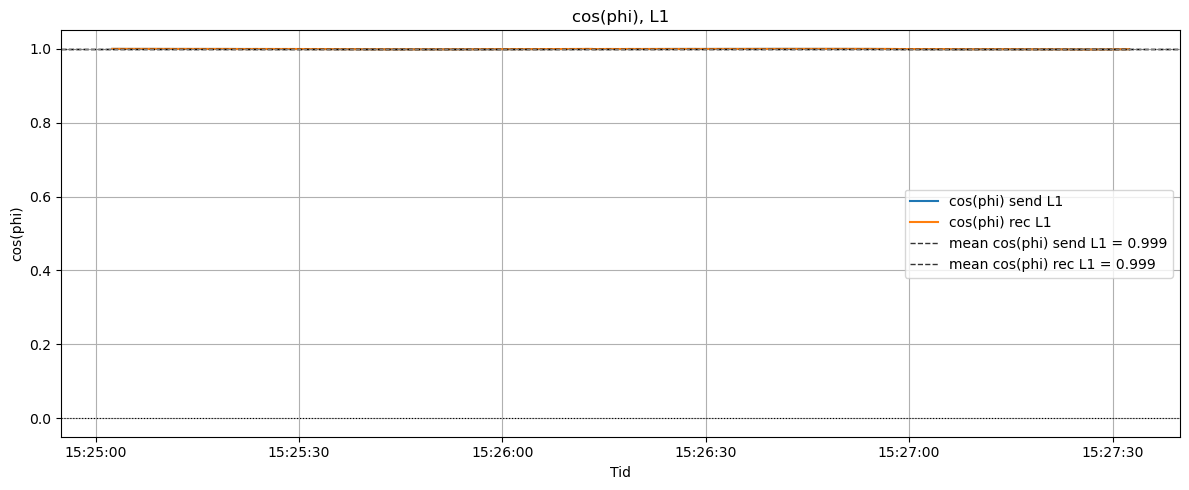

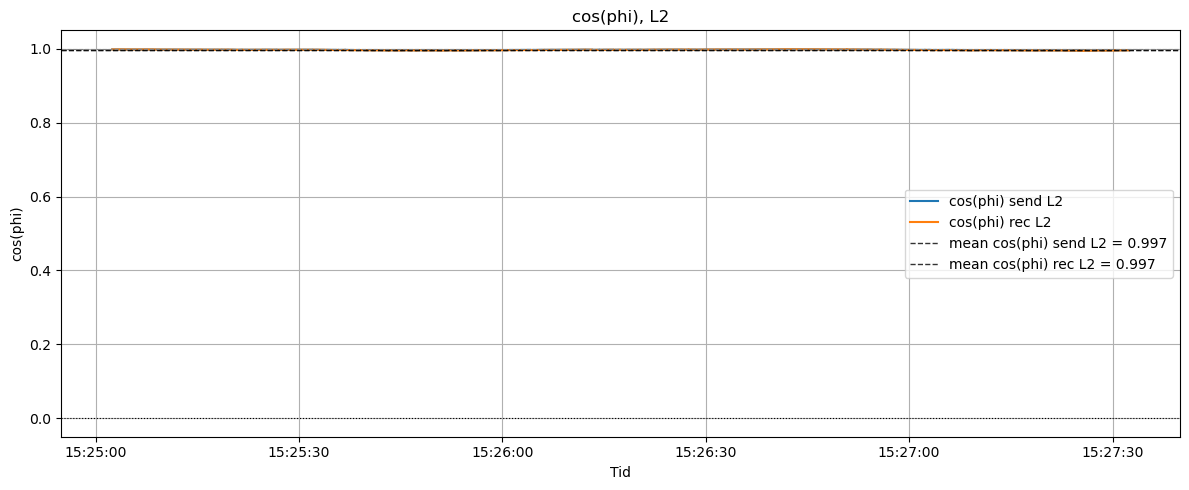

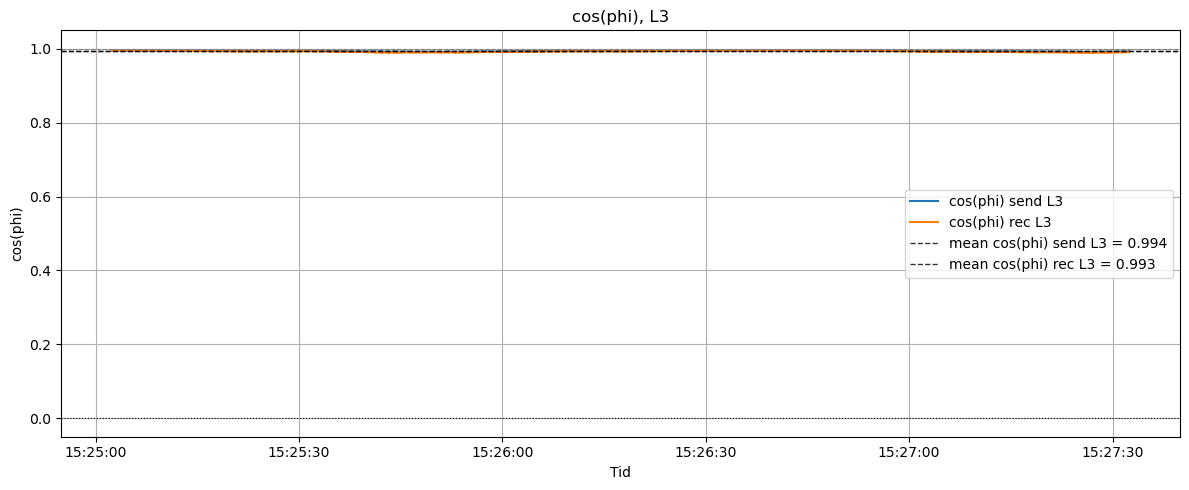

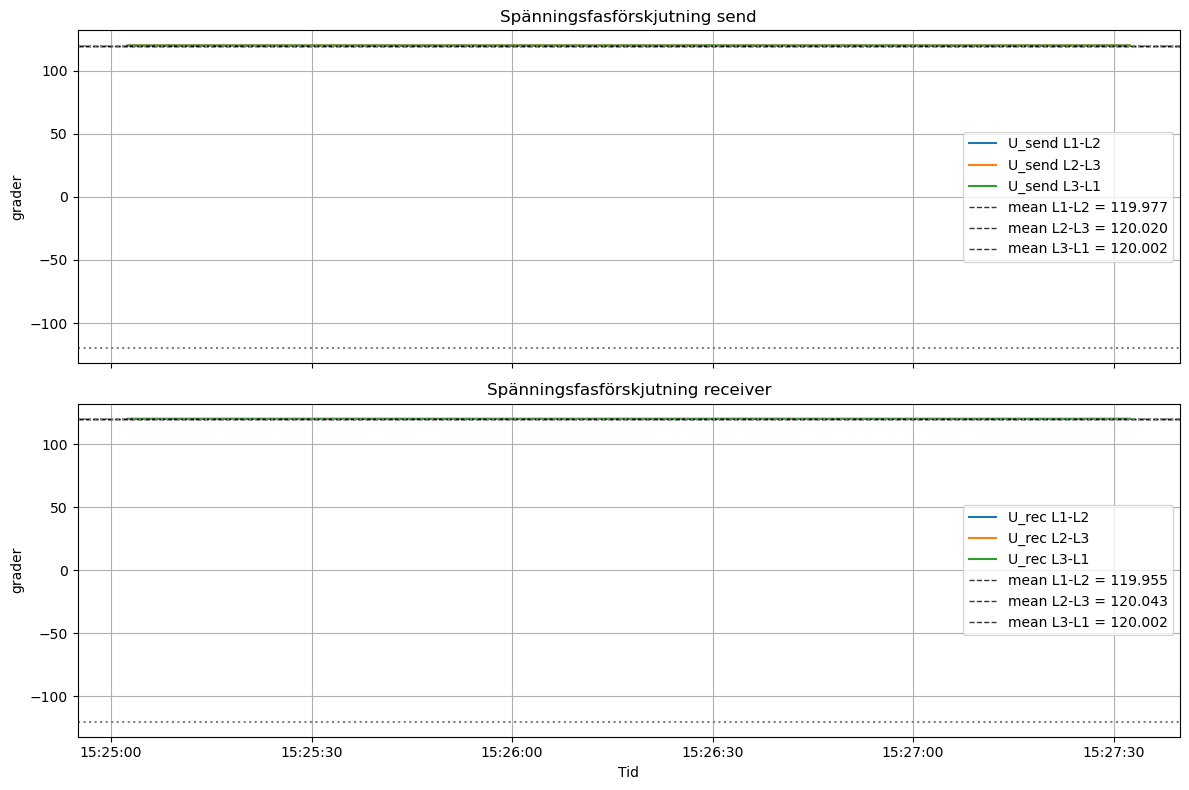

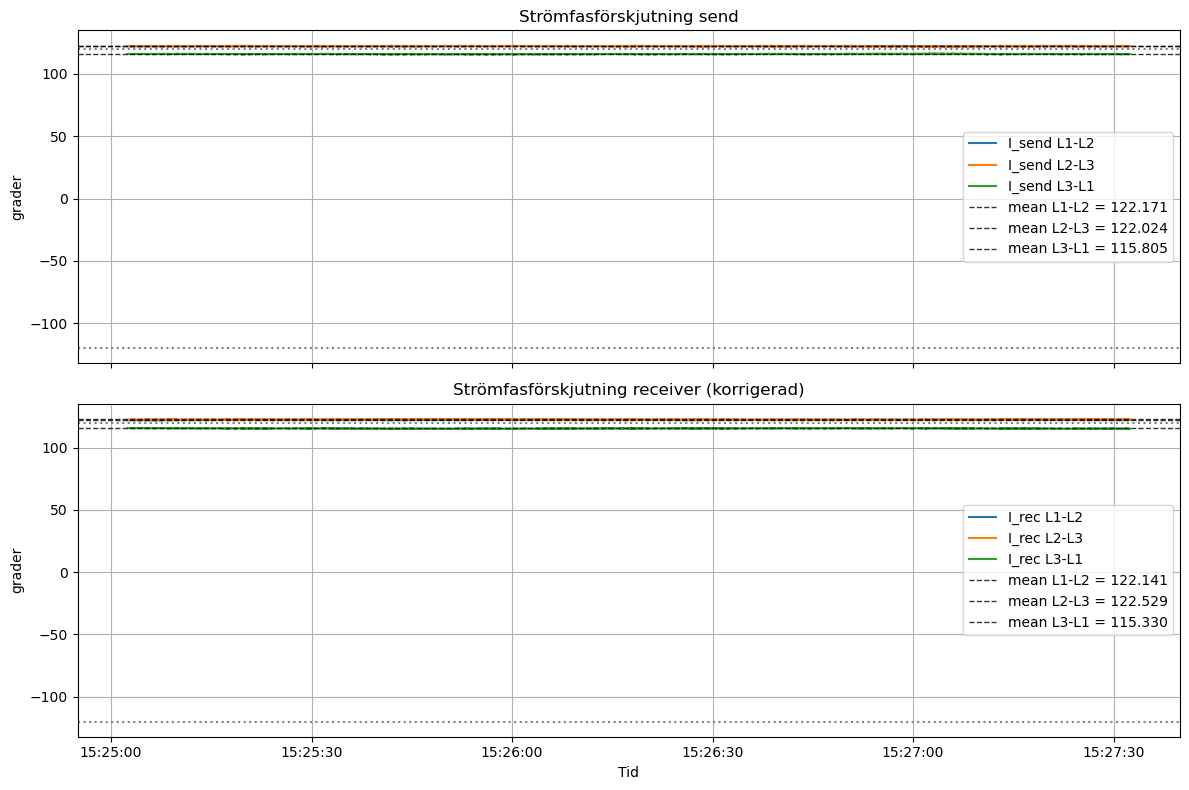

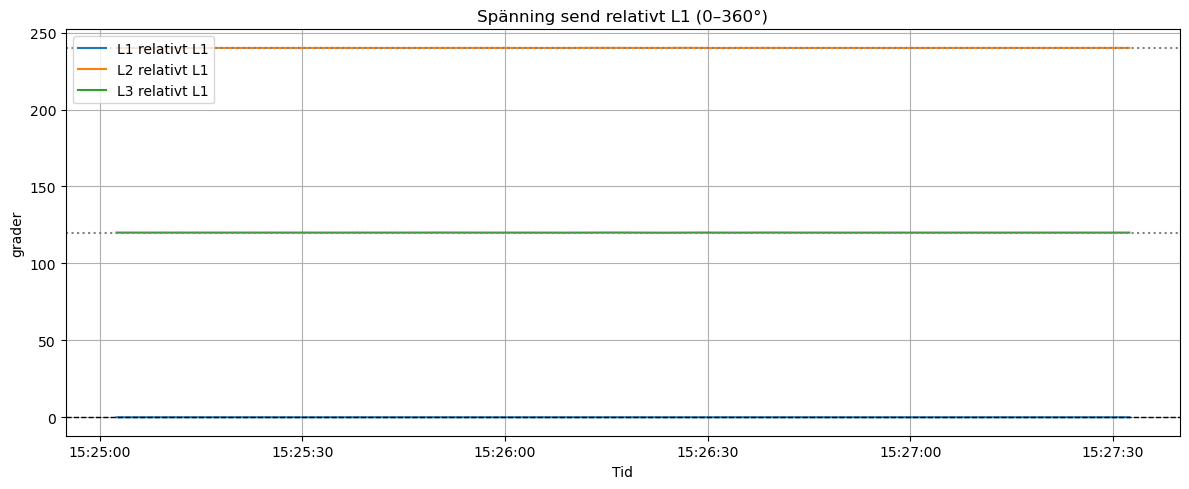

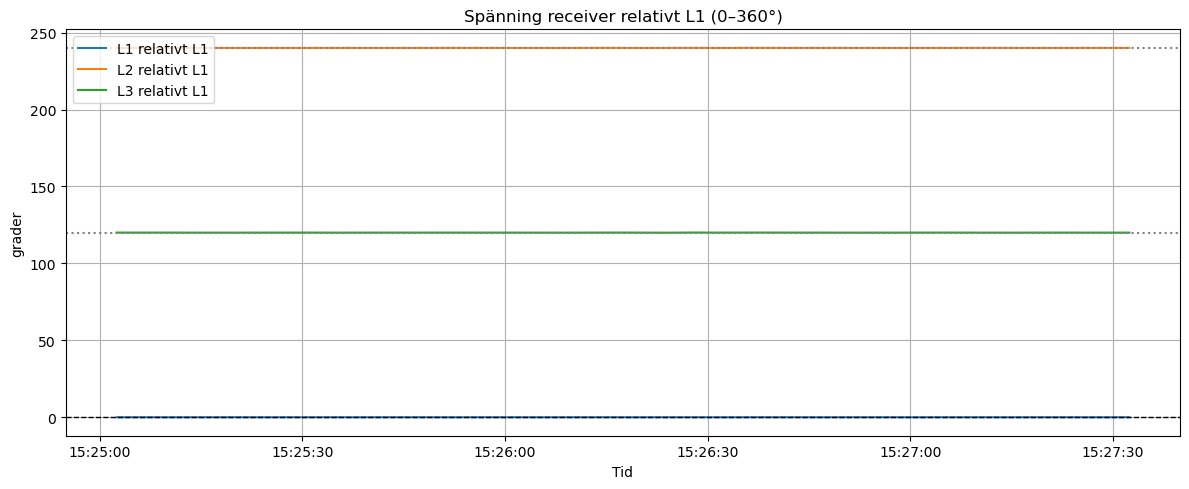

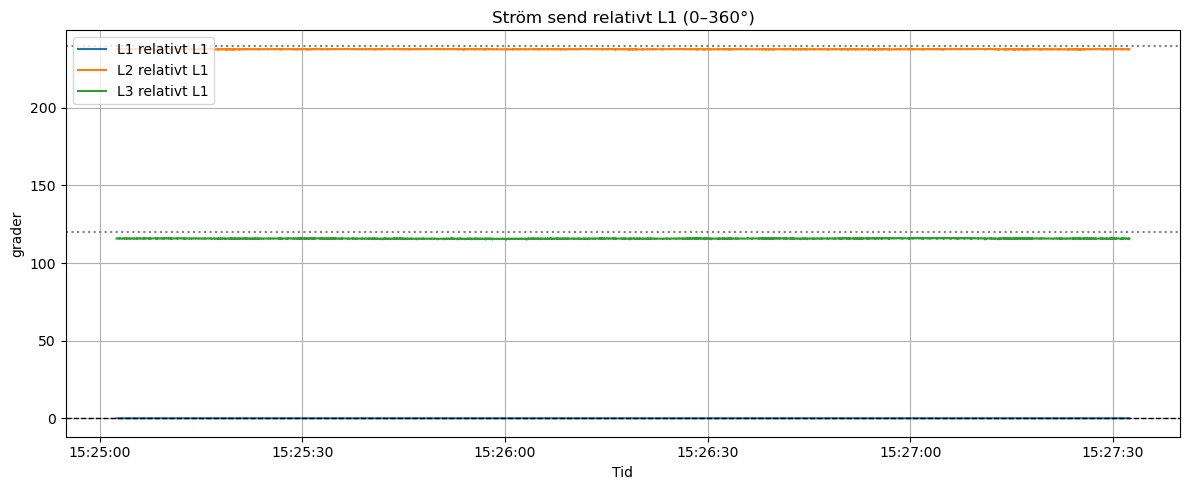

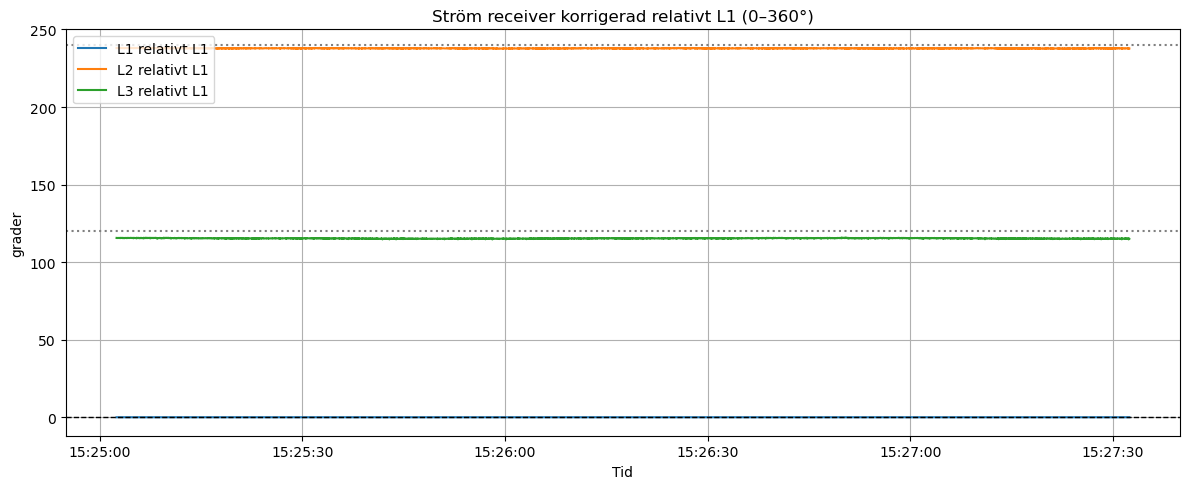

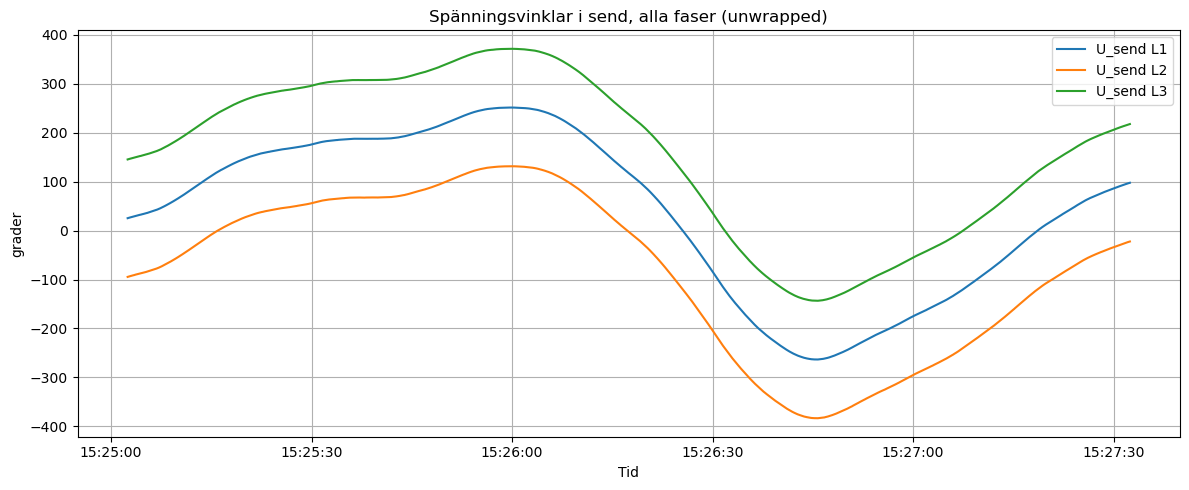

In [4]:
# ============================================================
# EXTRA ANALYS FÖR out_actual
# - phi och cos(phi)
# - fasförskjutning mellan L1, L2, L3
# - relativt L1
# - unwrapped-vinkelplottar
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# HJÄLPFUNKTIONER
# ============================================================

def wrap_angle_deg(angle_deg):
    return (angle_deg + 180.0) % 360.0 - 180.0

def to_360(angle_deg):
    return angle_deg % 360.0

def circular_mean_deg(angle_deg):
    angle_deg = np.asarray(angle_deg, dtype=float)
    angle_deg = angle_deg[~np.isnan(angle_deg)]
    if len(angle_deg) == 0:
        return np.nan
    angle_rad = np.deg2rad(angle_deg)
    return np.rad2deg(np.angle(np.mean(np.exp(1j * angle_rad))))

def add_mean_line(ax, y, label_prefix="mean", circular=False, color="black"):
    if circular:
        mean_val = circular_mean_deg(y)
    else:
        mean_val = np.nanmean(y)
    ax.axhline(mean_val, linestyle="--", linewidth=1.0, color=color, alpha=0.8,
               label=f"{label_prefix} = {mean_val:.3f}")
    return mean_val

def unwrap_deg(angle_deg_series):
    angle_rad = np.deg2rad(np.asarray(angle_deg_series, dtype=float))
    return np.rad2deg(np.unwrap(angle_rad))

# ============================================================
# ARBETA MED ACTUAL-FALLET
# ============================================================

out = out_actual.copy()

# ============================================================
# 1. LÄGG TILL RAW/CORR-VINKLAR FÖR MOTTAGARSTRÖM
# Din run_scenario sparar bara I_ang_R_use
# För actual är I_ang_R_use = korrigerad mottagarström
# ============================================================

for ph in ["L1", "L2", "L3"]:
    # korrigerad mottagarvinkel finns redan som use
    out[f"I_ang_R_corr_{ph}"] = out[f"I_ang_R_use_{ph}"]

    # rå mottagarvinkel = korrigerad - 180°
    out[f"I_ang_R_raw_{ph}"] = wrap_angle_deg(out[f"I_ang_R_corr_{ph}"] - 180.0)

# ============================================================
# 2. PHI OCH COS(PHI)
# ============================================================

for ph in ["L1", "L2", "L3"]:
    # vinkel mellan U och I i send
    out[f"phi_send_deg_{ph}"] = wrap_angle_deg(out[f"U_ang_S_{ph}"] - out[f"I_ang_S_{ph}"])

    # vinkel mellan U och I i receiver
    out[f"phi_rec_deg_{ph}"] = wrap_angle_deg(out[f"U_ang_R_use_{ph}"] - out[f"I_ang_R_use_{ph}"])

    # cos(phi)
    out[f"cosphi_send_{ph}"] = np.cos(np.deg2rad(out[f"phi_send_deg_{ph}"]))
    out[f"cosphi_rec_{ph}"]  = np.cos(np.deg2rad(out[f"phi_rec_deg_{ph}"]))

# ============================================================
# 3. FASFÖRSKJUTNING MELLAN L1, L2, L3
# ============================================================

# Spänning send
out["dU_send_L1_L2"] = wrap_angle_deg(out["U_ang_S_L1"] - out["U_ang_S_L2"])
out["dU_send_L2_L3"] = wrap_angle_deg(out["U_ang_S_L2"] - out["U_ang_S_L3"])
out["dU_send_L3_L1"] = wrap_angle_deg(out["U_ang_S_L3"] - out["U_ang_S_L1"])

# Spänning receiver
out["dU_rec_L1_L2"] = wrap_angle_deg(out["U_ang_R_use_L1"] - out["U_ang_R_use_L2"])
out["dU_rec_L2_L3"] = wrap_angle_deg(out["U_ang_R_use_L2"] - out["U_ang_R_use_L3"])
out["dU_rec_L3_L1"] = wrap_angle_deg(out["U_ang_R_use_L3"] - out["U_ang_R_use_L1"])

# Ström send
out["dI_send_L1_L2"] = wrap_angle_deg(out["I_ang_S_L1"] - out["I_ang_S_L2"])
out["dI_send_L2_L3"] = wrap_angle_deg(out["I_ang_S_L2"] - out["I_ang_S_L3"])
out["dI_send_L3_L1"] = wrap_angle_deg(out["I_ang_S_L3"] - out["I_ang_S_L1"])

# Ström receiver korrigerad
out["dI_rec_L1_L2"] = wrap_angle_deg(out["I_ang_R_use_L1"] - out["I_ang_R_use_L2"])
out["dI_rec_L2_L3"] = wrap_angle_deg(out["I_ang_R_use_L2"] - out["I_ang_R_use_L3"])
out["dI_rec_L3_L1"] = wrap_angle_deg(out["I_ang_R_use_L3"] - out["I_ang_R_use_L1"])

# ============================================================
# 4. RELATIVT L1 I [0,360)
# ============================================================

for prefix in ["U_ang_S", "U_ang_R_use", "I_ang_S", "I_ang_R_use"]:
    L1 = out[f"{prefix}_L1"]
    L2 = out[f"{prefix}_L2"]
    L3 = out[f"{prefix}_L3"]

    out[f"{prefix}_L1_rel_360"] = to_360(wrap_angle_deg(L1 - L1))
    out[f"{prefix}_L2_rel_360"] = to_360(wrap_angle_deg(L2 - L1))
    out[f"{prefix}_L3_rel_360"] = to_360(wrap_angle_deg(L3 - L1))

# ============================================================
# 5. SAMMANFATTNINGSTABELLER
# ============================================================

phi_rows = []
for ph in ["L1", "L2", "L3"]:
    phi_rows.append({
        "Phase": ph,
        "phi_send_mean_deg": circular_mean_deg(out[f"phi_send_deg_{ph}"]),
        "phi_rec_mean_deg": circular_mean_deg(out[f"phi_rec_deg_{ph}"]),
        "cosphi_send_mean": np.nanmean(out[f"cosphi_send_{ph}"]),
        "cosphi_rec_mean": np.nanmean(out[f"cosphi_rec_{ph}"]),
        "phi_send_std_deg": np.nanstd(out[f"phi_send_deg_{ph}"]),
        "phi_rec_std_deg": np.nanstd(out[f"phi_rec_deg_{ph}"]),
    })

phi_summary_df = pd.DataFrame(phi_rows)

phase_shift_summary = pd.DataFrame([
    {
        "Signal": "U_send",
        "L1-L2 mean deg": circular_mean_deg(out["dU_send_L1_L2"]),
        "L2-L3 mean deg": circular_mean_deg(out["dU_send_L2_L3"]),
        "L3-L1 mean deg": circular_mean_deg(out["dU_send_L3_L1"]),
        "L1 rel 0-360": to_360(circular_mean_deg(out["U_ang_S_L1_rel_360"])),
        "L2 rel 0-360": to_360(circular_mean_deg(out["U_ang_S_L2_rel_360"])),
        "L3 rel 0-360": to_360(circular_mean_deg(out["U_ang_S_L3_rel_360"])),
    },
    {
        "Signal": "U_rec",
        "L1-L2 mean deg": circular_mean_deg(out["dU_rec_L1_L2"]),
        "L2-L3 mean deg": circular_mean_deg(out["dU_rec_L2_L3"]),
        "L3-L1 mean deg": circular_mean_deg(out["dU_rec_L3_L1"]),
        "L1 rel 0-360": to_360(circular_mean_deg(out["U_ang_R_use_L1_rel_360"])),
        "L2 rel 0-360": to_360(circular_mean_deg(out["U_ang_R_use_L2_rel_360"])),
        "L3 rel 0-360": to_360(circular_mean_deg(out["U_ang_R_use_L3_rel_360"])),
    },
    {
        "Signal": "I_send",
        "L1-L2 mean deg": circular_mean_deg(out["dI_send_L1_L2"]),
        "L2-L3 mean deg": circular_mean_deg(out["dI_send_L2_L3"]),
        "L3-L1 mean deg": circular_mean_deg(out["dI_send_L3_L1"]),
        "L1 rel 0-360": to_360(circular_mean_deg(out["I_ang_S_L1_rel_360"])),
        "L2 rel 0-360": to_360(circular_mean_deg(out["I_ang_S_L2_rel_360"])),
        "L3 rel 0-360": to_360(circular_mean_deg(out["I_ang_S_L3_rel_360"])),
    },
    {
        "Signal": "I_rec_corr",
        "L1-L2 mean deg": circular_mean_deg(out["dI_rec_L1_L2"]),
        "L2-L3 mean deg": circular_mean_deg(out["dI_rec_L2_L3"]),
        "L3-L1 mean deg": circular_mean_deg(out["dI_rec_L3_L1"]),
        "L1 rel 0-360": to_360(circular_mean_deg(out["I_ang_R_use_L1_rel_360"])),
        "L2 rel 0-360": to_360(circular_mean_deg(out["I_ang_R_use_L2_rel_360"])),
        "L3 rel 0-360": to_360(circular_mean_deg(out["I_ang_R_use_L3_rel_360"])),
    },
])

print("\nPHI OCH COS(PHI):")
display(phi_summary_df)

print("\nFASFÖRSKJUTNING MELLAN L1, L2, L3:")
display(phase_shift_summary)

# ============================================================
# 6. SPARA EXTRA TABELLER
# ============================================================

phi_summary_df.to_excel(output_dir / "phi_cosphi_summary.xlsx", index=False)
phase_shift_summary.to_excel(output_dir / "phase_shift_summary.xlsx", index=False)
out.reset_index().to_excel(output_dir / "results_actual_extended.xlsx", index=False)

print("Extra tabeller sparade i:", output_dir)

# ============================================================
# 7. PLOTTA PHI
# ============================================================

for ph in ["L1", "L2", "L3"]:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(out.index, out[f"phi_send_deg_{ph}"], label=f"phi send {ph}")
    ax.plot(out.index, out[f"phi_rec_deg_{ph}"], label=f"phi rec {ph}")
    add_mean_line(ax, out[f"phi_send_deg_{ph}"], label_prefix=f"mean phi send {ph}", circular=True)
    add_mean_line(ax, out[f"phi_rec_deg_{ph}"], label_prefix=f"mean phi rec {ph}", circular=True)
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_title(f"Vinkel mellan spänning och ström, {ph}")
    ax.set_ylabel("grader")
    ax.set_xlabel("Tid")
    ax.grid(True)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_dir / f"plot_phi_{ph}.png", dpi=200)
    plt.show()

# ============================================================
# 8. PLOTTA COS(PHI)
# ============================================================

for ph in ["L1", "L2", "L3"]:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(out.index, out[f"cosphi_send_{ph}"], label=f"cos(phi) send {ph}")
    ax.plot(out.index, out[f"cosphi_rec_{ph}"], label=f"cos(phi) rec {ph}")
    add_mean_line(ax, out[f"cosphi_send_{ph}"], label_prefix=f"mean cos(phi) send {ph}")
    add_mean_line(ax, out[f"cosphi_rec_{ph}"], label_prefix=f"mean cos(phi) rec {ph}")
    ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8)
    ax.axhline(0.0, color="black", linestyle=":", linewidth=0.8)
    ax.set_title(f"cos(phi), {ph}")
    ax.set_ylabel("cos(phi)")
    ax.set_xlabel("Tid")
    ax.grid(True)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_dir / f"plot_cosphi_{ph}.png", dpi=200)
    plt.show()

# ============================================================
# 9. PLOTTA FASFÖRSKJUTNING MELLAN L1, L2, L3
# ============================================================

# Spänningsfaser send/receiver
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axs[0].plot(out.index, out["dU_send_L1_L2"], label="U_send L1-L2")
axs[0].plot(out.index, out["dU_send_L2_L3"], label="U_send L2-L3")
axs[0].plot(out.index, out["dU_send_L3_L1"], label="U_send L3-L1")
add_mean_line(axs[0], out["dU_send_L1_L2"], label_prefix="mean L1-L2", circular=True)
add_mean_line(axs[0], out["dU_send_L2_L3"], label_prefix="mean L2-L3", circular=True)
add_mean_line(axs[0], out["dU_send_L3_L1"], label_prefix="mean L3-L1", circular=True)
axs[0].axhline(120, color="gray", linestyle=":")
axs[0].axhline(-120, color="gray", linestyle=":")
axs[0].set_title("Spänningsfasförskjutning send")
axs[0].set_ylabel("grader")
axs[0].grid(True)
axs[0].legend()

axs[1].plot(out.index, out["dU_rec_L1_L2"], label="U_rec L1-L2")
axs[1].plot(out.index, out["dU_rec_L2_L3"], label="U_rec L2-L3")
axs[1].plot(out.index, out["dU_rec_L3_L1"], label="U_rec L3-L1")
add_mean_line(axs[1], out["dU_rec_L1_L2"], label_prefix="mean L1-L2", circular=True)
add_mean_line(axs[1], out["dU_rec_L2_L3"], label_prefix="mean L2-L3", circular=True)
add_mean_line(axs[1], out["dU_rec_L3_L1"], label_prefix="mean L3-L1", circular=True)
axs[1].axhline(120, color="gray", linestyle=":")
axs[1].axhline(-120, color="gray", linestyle=":")
axs[1].set_title("Spänningsfasförskjutning receiver")
axs[1].set_ylabel("grader")
axs[1].set_xlabel("Tid")
axs[1].grid(True)
axs[1].legend()

fig.tight_layout()
fig.savefig(output_dir / "plot_phase_shift_voltage.png", dpi=200)
plt.show()

# Strömfaser send/receiver
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axs[0].plot(out.index, out["dI_send_L1_L2"], label="I_send L1-L2")
axs[0].plot(out.index, out["dI_send_L2_L3"], label="I_send L2-L3")
axs[0].plot(out.index, out["dI_send_L3_L1"], label="I_send L3-L1")
add_mean_line(axs[0], out["dI_send_L1_L2"], label_prefix="mean L1-L2", circular=True)
add_mean_line(axs[0], out["dI_send_L2_L3"], label_prefix="mean L2-L3", circular=True)
add_mean_line(axs[0], out["dI_send_L3_L1"], label_prefix="mean L3-L1", circular=True)
axs[0].axhline(120, color="gray", linestyle=":")
axs[0].axhline(-120, color="gray", linestyle=":")
axs[0].set_title("Strömfasförskjutning send")
axs[0].set_ylabel("grader")
axs[0].grid(True)
axs[0].legend()

axs[1].plot(out.index, out["dI_rec_L1_L2"], label="I_rec L1-L2")
axs[1].plot(out.index, out["dI_rec_L2_L3"], label="I_rec L2-L3")
axs[1].plot(out.index, out["dI_rec_L3_L1"], label="I_rec L3-L1")
add_mean_line(axs[1], out["dI_rec_L1_L2"], label_prefix="mean L1-L2", circular=True)
add_mean_line(axs[1], out["dI_rec_L2_L3"], label_prefix="mean L2-L3", circular=True)
add_mean_line(axs[1], out["dI_rec_L3_L1"], label_prefix="mean L3-L1", circular=True)
axs[1].axhline(120, color="gray", linestyle=":")
axs[1].axhline(-120, color="gray", linestyle=":")
axs[1].set_title("Strömfasförskjutning receiver (korrigerad)")
axs[1].set_ylabel("grader")
axs[1].set_xlabel("Tid")
axs[1].grid(True)
axs[1].legend()

fig.tight_layout()
fig.savefig(output_dir / "plot_phase_shift_current.png", dpi=200)
plt.show()

# ============================================================
# 10. PLOTTA RELATIVT L1 I [0,360) OCH UNWRAPPED
# ============================================================

for prefix, title in [
    ("U_ang_S", "Spänning send relativt L1"),
    ("U_ang_R_use", "Spänning receiver relativt L1"),
    ("I_ang_S", "Ström send relativt L1"),
    ("I_ang_R_use", "Ström receiver korrigerad relativt L1"),
]:
    fig, ax = plt.subplots(figsize=(12,5))
    ax.plot(out.index, out[f"{prefix}_L1_rel_360"], label="L1 relativt L1")
    ax.plot(out.index, out[f"{prefix}_L2_rel_360"], label="L2 relativt L1")
    ax.plot(out.index, out[f"{prefix}_L3_rel_360"], label="L3 relativt L1")
    ax.axhline(0, color="black", linestyle="--", linewidth=1.0)
    ax.axhline(120, color="gray", linestyle=":")
    ax.axhline(240, color="gray", linestyle=":")
    ax.set_title(title + " (0–360°)")
    ax.set_ylabel("grader")
    ax.set_xlabel("Tid")
    ax.grid(True)
    ax.legend()
    fig.tight_layout()
    fig.savefig(output_dir / f"plot_relative_to_L1_{prefix}.png", dpi=200)
    plt.show()

# extra: unwrapped send-spänningsvinklar
def unwrap_deg(angle_deg_series):
    angle_rad = np.deg2rad(np.asarray(angle_deg_series, dtype=float))
    return np.rad2deg(np.unwrap(angle_rad))

fig, ax = plt.subplots(figsize=(12, 5))
for ph in ["L1", "L2", "L3"]:
    ax.plot(out.index, unwrap_deg(out[f"U_ang_S_{ph}"]), label=f"U_send {ph}")
ax.set_title("Spänningsvinklar i send, alla faser (unwrapped)")
ax.set_ylabel("grader")
ax.set_xlabel("Tid")
ax.grid(True)
ax.legend()
fig.tight_layout()
fig.savefig(output_dir / "plot_U_angles_send_all_unwrapped.png", dpi=200)
plt.show()

R_ref Bohus = 1.257525 Ω
alpha = 0.00403 1/K
T_ref = 20.0 °C


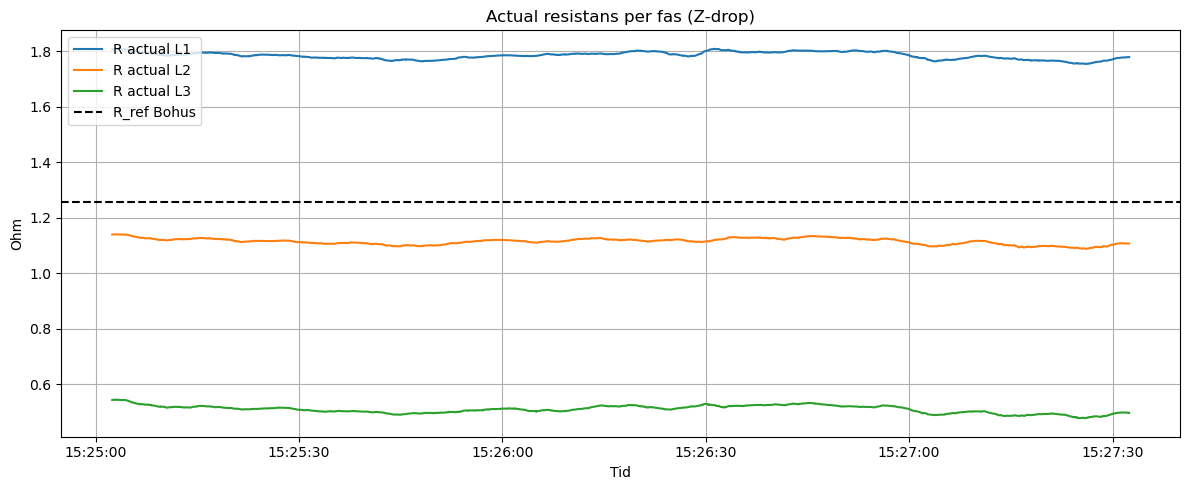


OFFSET MOT BOHUS R_ref


,Phase,R_mean_actual,R_ref_target,Delta_R_to_ref
0,L1,1.784722,1.257525,-0.527197
1,L2,1.114641,1.257525,0.142884
2,L3,0.509709,1.257525,0.747816



OFFSET MOT GEMENSAMT MEDELVÄRDE


,Phase,R_mean_actual,R_target_common,Delta_R_to_common
0,L1,1.784722,1.136358,-0.648365
1,L2,1.114641,1.136358,0.021716
2,L3,0.509709,1.136358,0.626648


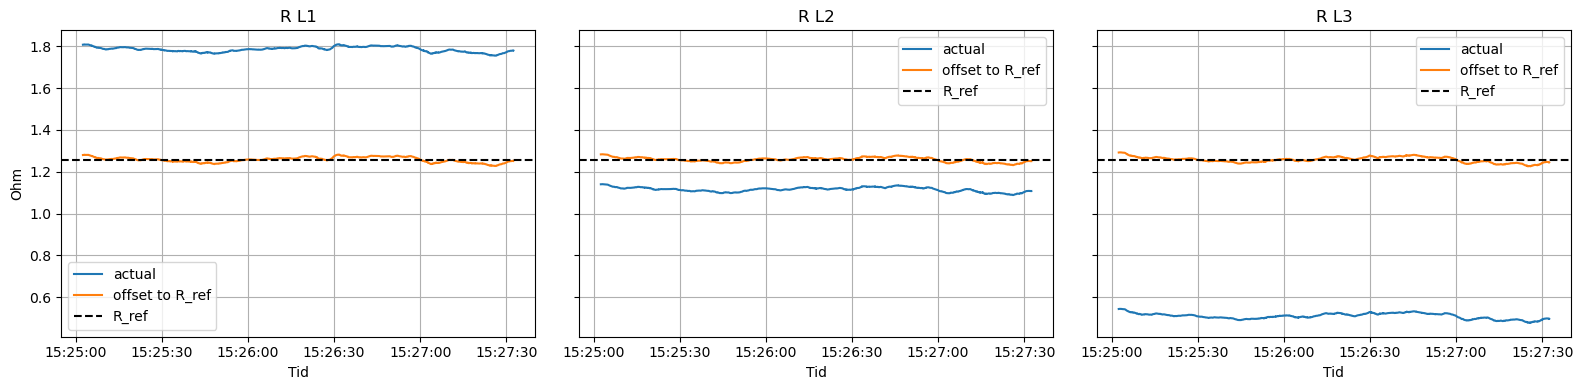

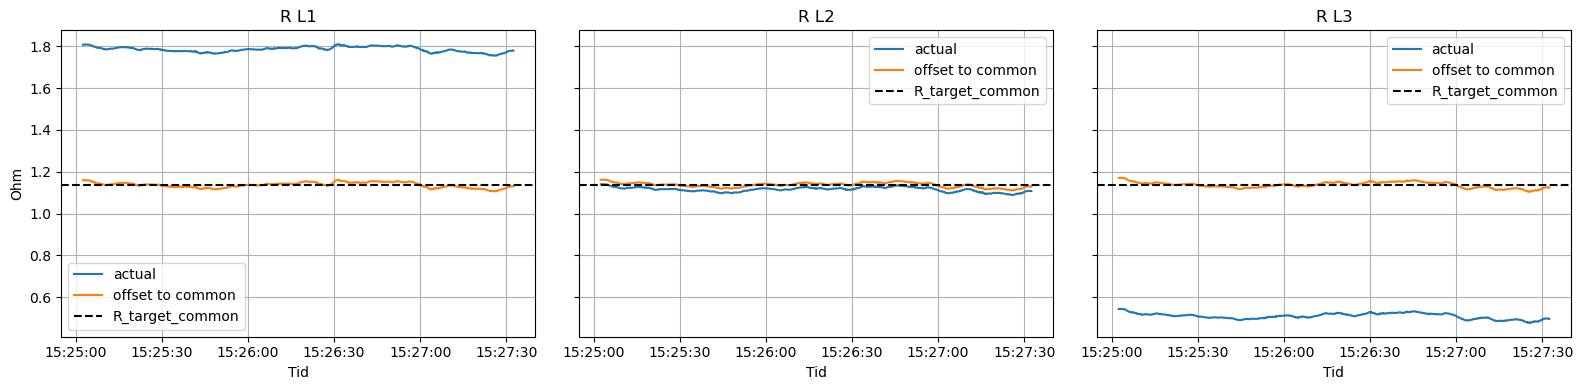

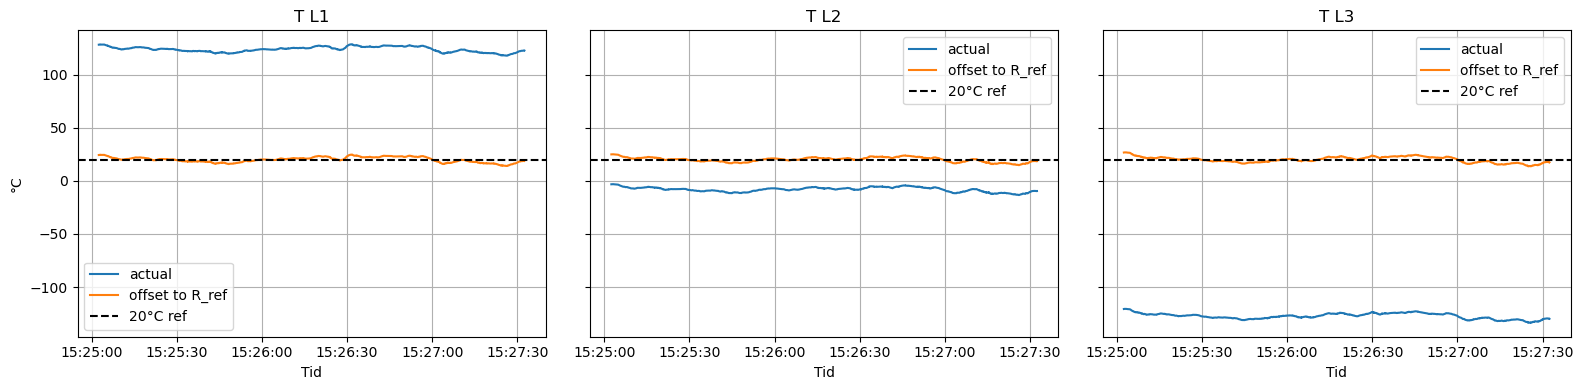

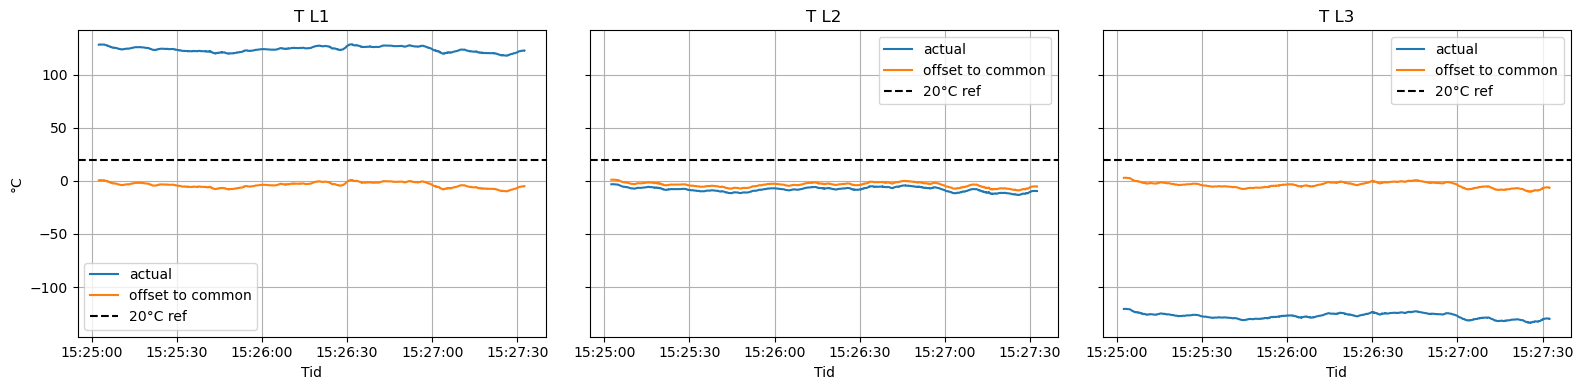


SAMMANFATTNING OFFSET-TEST


,Phase,R_actual_mean,T_actual_mean,R_corr_ref_mean,T_corr_ref_mean,R_corr_common_mean,T_corr_common_mean
0,L1,1.784722,124.028320,1.257525,20.0,1.136358,-3.909147
1,L2,1.114641,-8.194314,1.257525,20.0,1.136358,-3.909147
2,L3,0.509709,-127.561448,1.257525,20.0,1.136358,-3.909147


In [5]:
# ============================================================
# ACTUAL R + RESISTANSOFFSET PER FAS
# Kör efter att out_actual redan finns
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PARAMETRAR FÖR BOHUS
# ============================================================

R_ref = 0.0729 * 17.25
alpha = 0.00403
T_ref = 20.0

print(f"R_ref Bohus = {R_ref:.6f} Ω")
print(f"alpha = {alpha:.5f} 1/K")
print(f"T_ref = {T_ref:.1f} °C")

# ============================================================
# 1. HÄMTA RESISTANSKOLUMNER FRÅN out_actual
# ============================================================

R_cols = {
    "L1": "R_L1",
    "L2": "R_L2",
    "L3": "R_L3",
}

missing_cols = [c for c in R_cols.values() if c not in out_actual.columns]
if missing_cols:
    raise ValueError(f"Saknade kolumner i out_actual: {missing_cols}")

# ============================================================
# 2. PLOTTA ACTUAL-RESISTANSER
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))
for ph, col in R_cols.items():
    ax.plot(out_actual.index, out_actual[col], label=f"R actual {ph}")
ax.axhline(R_ref, color="black", linestyle="--", label="R_ref Bohus")
ax.set_title("Actual resistans per fas (Z-drop)")
ax.set_ylabel("Ohm")
ax.set_xlabel("Tid")
ax.grid(True)
ax.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 3. BERÄKNA ACTUAL-TEMPERATUR FRÅN R
# ============================================================

actual_T = pd.DataFrame(index=out_actual.index)

for ph, col in R_cols.items():
    actual_T[f"T_actual_{ph}"] = ((out_actual[col] / R_ref) - 1.0) / alpha + T_ref

# ============================================================
# 4. BERÄKNA OFFSET MOT BOHUS R_ref
# ============================================================

offset_to_ref_rows = []
for ph, col in R_cols.items():
    R_mean = np.nanmean(out_actual[col])
    dR = R_ref - R_mean

    offset_to_ref_rows.append({
        "Phase": ph,
        "R_mean_actual": R_mean,
        "R_ref_target": R_ref,
        "Delta_R_to_ref": dR,
    })

offset_to_ref_df = pd.DataFrame(offset_to_ref_rows)

print("\nOFFSET MOT BOHUS R_ref")
display(offset_to_ref_df)

# skapa korrigerad resistans/temperatur
out_refcorr = out_actual.copy()
for ph, col in R_cols.items():
    dR = offset_to_ref_df.loc[offset_to_ref_df["Phase"] == ph, "Delta_R_to_ref"].iloc[0]
    out_refcorr[f"R_corr_ref_{ph}"] = out_actual[col] + dR
    out_refcorr[f"T_corr_ref_{ph}"] = ((out_refcorr[f"R_corr_ref_{ph}"] / R_ref) - 1.0) / alpha + T_ref

# ============================================================
# 5. BERÄKNA OFFSET MOT GEMENSAMT MEDELVÄRDE
# ============================================================

R_target_common = np.nanmean([
    np.nanmean(out_actual[R_cols["L1"]]),
    np.nanmean(out_actual[R_cols["L2"]]),
    np.nanmean(out_actual[R_cols["L3"]]),
])

offset_to_common_rows = []
for ph, col in R_cols.items():
    R_mean = np.nanmean(out_actual[col])
    dR = R_target_common - R_mean

    offset_to_common_rows.append({
        "Phase": ph,
        "R_mean_actual": R_mean,
        "R_target_common": R_target_common,
        "Delta_R_to_common": dR,
    })

offset_to_common_df = pd.DataFrame(offset_to_common_rows)

print("\nOFFSET MOT GEMENSAMT MEDELVÄRDE")
display(offset_to_common_df)

# skapa korrigerad resistans/temperatur
out_commoncorr = out_actual.copy()
for ph, col in R_cols.items():
    dR = offset_to_common_df.loc[offset_to_common_df["Phase"] == ph, "Delta_R_to_common"].iloc[0]
    out_commoncorr[f"R_corr_common_{ph}"] = out_actual[col] + dR
    out_commoncorr[f"T_corr_common_{ph}"] = ((out_commoncorr[f"R_corr_common_{ph}"] / R_ref) - 1.0) / alpha + T_ref

# ============================================================
# 6. PLOTTA ACTUAL vs R_ref-OFFSET
# ============================================================

fig, axs = plt.subplots(1, 3, figsize=(16,4), sharey=True)
for i, ph in enumerate(["L1","L2","L3"]):
    axs[i].plot(out_actual.index, out_actual[R_cols[ph]], label="actual")
    axs[i].plot(out_refcorr.index, out_refcorr[f"R_corr_ref_{ph}"], label="offset to R_ref")
    axs[i].axhline(R_ref, color="black", linestyle="--", label="R_ref")
    axs[i].set_title(f"R {ph}")
    axs[i].set_xlabel("Tid")
    axs[i].grid(True)
    if i == 0:
        axs[i].set_ylabel("Ohm")
    axs[i].legend()
plt.tight_layout()
plt.show()

# ============================================================
# 7. PLOTTA ACTUAL vs GEMENSAM OFFSET
# ============================================================

fig, axs = plt.subplots(1, 3, figsize=(16,4), sharey=True)
for i, ph in enumerate(["L1","L2","L3"]):
    axs[i].plot(out_actual.index, out_actual[R_cols[ph]], label="actual")
    axs[i].plot(out_commoncorr.index, out_commoncorr[f"R_corr_common_{ph}"], label="offset to common")
    axs[i].axhline(R_target_common, color="black", linestyle="--", label="R_target_common")
    axs[i].set_title(f"R {ph}")
    axs[i].set_xlabel("Tid")
    axs[i].grid(True)
    if i == 0:
        axs[i].set_ylabel("Ohm")
    axs[i].legend()
plt.tight_layout()
plt.show()

# ============================================================
# 8. PLOTTA ACTUAL TEMPERATUR vs R_ref-OFFSET
# ============================================================

fig, axs = plt.subplots(1, 3, figsize=(16,4), sharey=True)
for i, ph in enumerate(["L1","L2","L3"]):
    axs[i].plot(actual_T.index, actual_T[f"T_actual_{ph}"], label="actual")
    axs[i].plot(out_refcorr.index, out_refcorr[f"T_corr_ref_{ph}"], label="offset to R_ref")
    axs[i].axhline(T_ref, color="black", linestyle="--", label="20°C ref")
    axs[i].set_title(f"T {ph}")
    axs[i].set_xlabel("Tid")
    axs[i].grid(True)
    if i == 0:
        axs[i].set_ylabel("°C")
    axs[i].legend()
plt.tight_layout()
plt.show()

# ============================================================
# 9. PLOTTA ACTUAL TEMPERATUR vs GEMENSAM OFFSET
# ============================================================

fig, axs = plt.subplots(1, 3, figsize=(16,4), sharey=True)
for i, ph in enumerate(["L1","L2","L3"]):
    axs[i].plot(actual_T.index, actual_T[f"T_actual_{ph}"], label="actual")
    axs[i].plot(out_commoncorr.index, out_commoncorr[f"T_corr_common_{ph}"], label="offset to common")
    axs[i].axhline(T_ref, color="black", linestyle="--", label="20°C ref")
    axs[i].set_title(f"T {ph}")
    axs[i].set_xlabel("Tid")
    axs[i].grid(True)
    if i == 0:
        axs[i].set_ylabel("°C")
    axs[i].legend()
plt.tight_layout()
plt.show()

# ============================================================
# 10. SAMMANFATTNINGSTABELL
# ============================================================

summary_offset_rows = []

for ph in ["L1","L2","L3"]:
    summary_offset_rows.append({
        "Phase": ph,
        "R_actual_mean": np.nanmean(out_actual[R_cols[ph]]),
        "T_actual_mean": np.nanmean(actual_T[f"T_actual_{ph}"]),
        "R_corr_ref_mean": np.nanmean(out_refcorr[f"R_corr_ref_{ph}"]),
        "T_corr_ref_mean": np.nanmean(out_refcorr[f"T_corr_ref_{ph}"]),
        "R_corr_common_mean": np.nanmean(out_commoncorr[f"R_corr_common_{ph}"]),
        "T_corr_common_mean": np.nanmean(out_commoncorr[f"T_corr_common_{ph}"]),
    })

summary_offset_df = pd.DataFrame(summary_offset_rows)

print("\nSAMMANFATTNING OFFSET-TEST")
display(summary_offset_df)